In [1]:
import sys
from __editable___warp_lang_1_13_0_dev0_finder import _EditableFinder

sys.meta_path.remove(_EditableFinder)
sys.meta_path.insert(0, _EditableFinder)

import numpy as np
import torch
import torch.nn.functional as F
import warp as wp

wp.clear_kernel_cache()
wp.init()


@wp.kernel
def _sample_1d(tex: wp.Texture1D, pos: wp.array(dtype=float), out: wp.array(dtype=float)):
    tid = wp.tid()
    out[tid] = wp.texture_sample(tex, pos[tid], dtype=float)


@wp.kernel
def _sample_2d(tex: wp.Texture2D, pos: wp.array(dtype=wp.vec2f), out: wp.array(dtype=float)):
    tid = wp.tid()
    out[tid] = wp.texture_sample(tex, pos[tid], dtype=float)


@wp.kernel
def _sample_3d(tex: wp.Texture3D, pos: wp.array(dtype=wp.vec3f), out: wp.array(dtype=float)):
    tid = wp.tid()
    out[tid] = wp.texture_sample(tex, pos[tid], dtype=float)


def warp_grad(tex_cls, kernel, pos_dtype, data, coord, **tex_kwargs):
    tex = tex_cls(data, normalized_coords=False, device="cpu", **tex_kwargs)
    c = [coord] if not hasattr(coord, "__len__") else [pos_dtype(*coord)]
    pos = wp.array(c, dtype=pos_dtype, requires_grad=True, device="cpu")
    out = wp.zeros(1, dtype=float, requires_grad=True, device="cpu")
    tape = wp.Tape()
    with tape:
        wp.launch(kernel, dim=1, inputs=[tex, pos], outputs=[out], device="cpu")
    out.grad = wp.ones(1, dtype=float, device="cpu")
    tape.backward()
    return pos.grad.numpy()[0]


def torch_grad_1d(data, u, padding_mode="border"):
    W = data.shape[0]
    t = torch.tensor(data, dtype=torch.float32)[None, None, None]
    grid = torch.tensor([[[[(u / W) * 2 - 1, 0.0]]]], dtype=torch.float32, requires_grad=True)
    F.grid_sample(t, grid, mode="bilinear", padding_mode=padding_mode, align_corners=False).backward()
    return float(grid.grad[0, 0, 0, 0] * (2 / W))


def torch_grad_2d(data, coord, padding_mode="border"):
    H, W = data.shape
    u, v = coord
    t = torch.tensor(data, dtype=torch.float32)[None, None]
    grid = torch.tensor([[[[(u / W) * 2 - 1, (v / H) * 2 - 1]]]], dtype=torch.float32, requires_grad=True)
    F.grid_sample(t, grid, mode="bilinear", padding_mode=padding_mode, align_corners=False).backward()
    g = grid.grad[0, 0, 0].numpy()
    return np.array([g[0] * (2 / W), g[1] * (2 / H)])


def torch_grad_3d(data, coord, padding_mode="border"):
    D, H, W = data.shape
    u, v, w = coord
    t = torch.tensor(data, dtype=torch.float32)[None, None]
    grid = torch.tensor(
        [[[[[(u / W) * 2 - 1, (v / H) * 2 - 1, (w / D) * 2 - 1]]]]], dtype=torch.float32, requires_grad=True
    )
    F.grid_sample(t, grid, mode="bilinear", padding_mode=padding_mode, align_corners=False).backward()
    g = grid.grad[0, 0, 0, 0].numpy()
    return np.array([g[0] * (2 / W), g[1] * (2 / H), g[2] * (2 / D)])


def print_table(title, rows):
    CW = max(len(r[0]) for r in rows)
    VW = max(max(len(str(np.round(np.atleast_1d(r[1]), 5))), len(str(np.round(np.atleast_1d(r[2]), 5)))) for r in rows)
    sep = "-" * (CW + 2 * VW + 20)
    print(f"\n{title}\n{sep}")
    print(f"{'coord':<{CW}}  {'warp':>{VW}}  {'torch':>{VW}}  {'max_err':>10}")
    print(sep)
    for label, wg, tg in rows:
        wg, tg = np.atleast_1d(wg), np.atleast_1d(tg)
        print(
            f"{label:<{CW}}  {str(np.round(wg, 5)):>{VW}}  {str(np.round(tg, 5)):>{VW}}  {np.abs(wg - tg).max():>10.2e}"
        )
    print(sep)


def warp_grad_1d_wrap(data, u):
    """Analytically verify WRAP gradient: d/du of linear interp with wrapped neighbors."""
    W = len(data)
    # raw texel coord
    tx = u - 0.5
    x0 = int(np.floor(tx)) % W
    x1 = (x0 + 1) % W
    return float(data[x1] - data[x0])


if __name__ == "__main__":
    rng = np.random.default_rng(0)
    d1 = rng.standard_normal(16).astype(np.float32)
    d2 = rng.standard_normal((6, 10)).astype(np.float32)
    d3 = rng.standard_normal((8, 6, 10)).astype(np.float32)

    # ── BORDER mode: compare against PyTorch ────────────────────────────────
    border = dict(filter_mode=wp.TextureFilterMode.LINEAR, address_mode=wp.TextureAddressMode.BORDER)

    print_table(
        "1D  BORDER",
        [
            (f"u={u}", warp_grad(wp.Texture1D, _sample_1d, float, d1, u, **border), torch_grad_1d(d1, u))
            for u in [0.1, 1.5, 7.3, 15.1, 15.9]
        ],
    )
    print_table(
        "2D  BORDER",
        [
            (f"uv={c}", warp_grad(wp.Texture2D, _sample_2d, wp.vec2f, d2, c, **border), torch_grad_2d(d2, c))
            for c in [(0.1, 0.1), (1.5, 1.5), (3.7, 2.3), (9.1, 5.1), (9.9, 5.9)]
        ],
    )
    print_table(
        "3D  BORDER",
        [
            (f"uvw={c}", warp_grad(wp.Texture3D, _sample_3d, wp.vec3f, d3, c, **border), torch_grad_3d(d3, c))
            for c in [(0.1, 0.1, 0.1), (1.5, 1.5, 1.5), (2.3, 3.7, 1.1), (9.1, 5.1, 7.1), (9.9, 5.9, 7.9)]
        ],
    )

    # ── CLAMP mode: compare against PyTorch (padding_mode="border" = clamp) ─
    clamp = dict(filter_mode=wp.TextureFilterMode.LINEAR, address_mode=wp.TextureAddressMode.CLAMP)

    print_table(
        "1D  CLAMP",
        [
            (f"u={u}", warp_grad(wp.Texture1D, _sample_1d, float, d1, u, **clamp), torch_grad_1d(d1, u, "border"))
            for u in [0.1, 1.5, 7.3, 15.1, 15.9]
        ],
    )
    print_table(
        "2D  CLAMP",
        [
            (f"uv={c}", warp_grad(wp.Texture2D, _sample_2d, wp.vec2f, d2, c, **clamp), torch_grad_2d(d2, c, "border"))
            for c in [(0.1, 0.1), (1.5, 1.5), (3.7, 2.3), (9.1, 5.1), (9.9, 5.9)]
        ],
    )
    print_table(
        "3D  CLAMP",
        [
            (f"uvw={c}", warp_grad(wp.Texture3D, _sample_3d, wp.vec3f, d3, c, **clamp), torch_grad_3d(d3, c, "border"))
            for c in [(0.1, 0.1, 0.1), (1.5, 1.5, 1.5), (2.3, 3.7, 1.1), (9.1, 5.1, 7.1), (9.9, 5.9, 7.9)]
        ],
    )

    # ── WRAP mode: compare against PyTorch (padding_mode="zeros" approximation)
    # PyTorch doesn't have a direct WRAP equivalent so we verify analytically
    # at boundary-crossing coords where the wrap matters.
    wrap = dict(filter_mode=wp.TextureFilterMode.LINEAR, address_mode=wp.TextureAddressMode.WRAP)

    wrap_coords_1d = [0.1, 1.5, 7.3, 15.1, 15.9]  # 0.1 and 15.9 straddle boundary
    rows_wrap_1d = []
    for u in wrap_coords_1d:
        wg = warp_grad(wp.Texture1D, _sample_1d, float, d1, u, **wrap)
        ag = warp_grad_1d_wrap(d1, u)  # analytical
        rows_wrap_1d.append((f"u={u}", np.atleast_1d(wg), np.atleast_1d(ag)))
    print_table("1D  WRAP  (vs analytical)", rows_wrap_1d)

    # For WRAP at non-boundary coords the gradient matches BORDER/CLAMP
    print_table(
        "1D  WRAP  interior (vs PyTorch BORDER)",
        [
            (f"u={u}", warp_grad(wp.Texture1D, _sample_1d, float, d1, u, **wrap), torch_grad_1d(d1, u))
            for u in [1.5, 7.3]
        ],
    )

    # ── MIRROR mode: interior points match BORDER; boundary analytical check ─
    mirror = dict(filter_mode=wp.TextureFilterMode.LINEAR, address_mode=wp.TextureAddressMode.MIRROR)

    print_table(
        "1D  MIRROR  interior (vs PyTorch BORDER)",
        [
            (f"u={u}", warp_grad(wp.Texture1D, _sample_1d, float, d1, u, **mirror), torch_grad_1d(d1, u))
            for u in [1.5, 7.3]
        ],
    )

    # At u=15.9 with MIRROR: x0=15, x1 mirrors to 14 → grad = data[14] - data[15]
    u_mirror = 15.9
    wg_mirror = warp_grad(wp.Texture1D, _sample_1d, float, d1, u_mirror, **mirror)
    W = len(d1)
    tx = u_mirror - 0.5
    x0 = int(np.floor(tx))  # 15
    # mirror of x1=16: period=32, m=16, m>=16 → 32-16-1=15... actually x1 mirrors to 14
    x1_raw = x0 + 1  # 16
    period = 2 * W  # 32
    m = x1_raw % period  # 16
    x1_mirrored = period - m - 1  # 15... wait, that's same as x0
    # correct mirror: m=16 >= W=16, so mirror = 32-16-1 = 15
    # but x0=15 too, so grad should be data[15]-data[15]=0? No:
    # cpu_apply_address_mode_1d with MIRROR gives tx in valid range first.
    # Let's just print and inspect.
    print(f"\n1D  MIRROR  boundary u={u_mirror}")
    print(f"  warp grad = {wg_mirror:.5f}")
    print(f"  data[14]={d1[14]:.5f}  data[15]={d1[15]:.5f}  (expected d[14]-d[15]={d1[14] - d1[15]:.5f})")

Warp 1.13.0.dev0 initialized:
   CUDA Toolkit 12.8, Driver 12.9
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX 6000 Ada Generation" (47 GiB, sm_89, mempool enabled)
   Kernel cache:
     /data/vision/polina/users/vivekg/xdg-cache/warp/1.13.0.dev0
Module __main__ 0d7e98c load on device 'cpu' took 1962.78 ms  (compiled)

1D  BORDER
----------------------------------------------
coord         warp       torch     max_err
----------------------------------------------
u=0.1         [0.]       [-0.]    0.00e+00
u=1.5    [0.77253]   [0.77253]    0.00e+00
u=7.3   [-0.35692]  [-0.35692]    0.00e+00
u=15.1   [0.51364]   [0.51364]    0.00e+00
u=15.9        [0.]        [0.]    0.00e+00
----------------------------------------------

2D  BORDER
-----------------------------------------------------------------------
coord                         warp                torch     max_err
-----------------------------------------------------------------------
uv=(0.1, 0.1)          

In [29]:
import numpy as np
import warp as wp

wp.init()


@wp.kernel
def sample(tex: wp.Texture1D, pos: wp.array(dtype=float), out: wp.array(dtype=float)):
    tid = wp.tid()
    out[tid] = wp.texture_sample(tex, pos[tid], dtype=float)


data = np.arange(16, dtype=np.float32)
tex = wp.Texture1D(data, normalized_coords=False)
pos = wp.array([4.0], dtype=float, requires_grad=True)
out = wp.zeros(1, dtype=float, requires_grad=True)

tape = wp.Tape()
with tape:
    wp.launch(sample, dim=1, inputs=[tex, pos], outputs=[out])
out.grad = wp.ones(1, dtype=float)
tape.backward()

print("out:", out.numpy())  # [3.5]
print("pos.grad:", pos.grad.numpy())  # [1.]

Module __main__ 5372883 load on device 'cuda:0' took 6055.33 ms  (compiled)
out: [3.5]
pos.grad: [1.]


In [1]:
!rm -rf /data/vision/polina/users/vivekg/xdg-cache/warp/1.13.0.dev0
!uv pip install -e warp/.

Resolved 2 packages in 16.68s                                        
Prepared 1 package in 3.21s                                              
Uninstalled 1 package in 130ms
Installed 1 package in 294ms0 (from file:///data/vision/poli
 ~ warp-lang==1.13.0.dev0 (from file:///data/vision/polina/users/vivekg/nanodrr/warp)


In [2]:
import sys

from __editable___warp_lang_1_13_0_dev0_finder import _EditableFinder

sys.meta_path.remove(_EditableFinder)
sys.meta_path.insert(0, _EditableFinder)

In [3]:
import warp as wp

In [12]:
import matplotlib.pyplot as plt

from nanodrr.camera import make_rt_inv, make_k_inv
from nanodrr.data import Subject
from nanodrr.drr import render as torch_render
from nanodrr.plot import plot_drr

In [5]:
subject = Subject.from_filepath("../DiffDRR/diffdrr/data/cxr.nii.gz", "../DiffDRR/diffdrr/data/mask.nii.gz").cuda()

In [6]:
k_inv = make_k_inv(1020.0, 2.0, 2.0, 0.0, 0.0, 200, 200).cuda()
rt_inv = make_rt_inv(
    torch.tensor([[0.0, 0.0, 0.0], [30.0, 0.0, 0.0]]).cuda(),
    torch.tensor([[0.0, 850.0, 0.0]]).cuda(),
    isocenter=subject.isocenter,
).cuda()
sdd = torch.tensor([1020.0]).cuda()

torch.Size([2, 119, 200, 200])


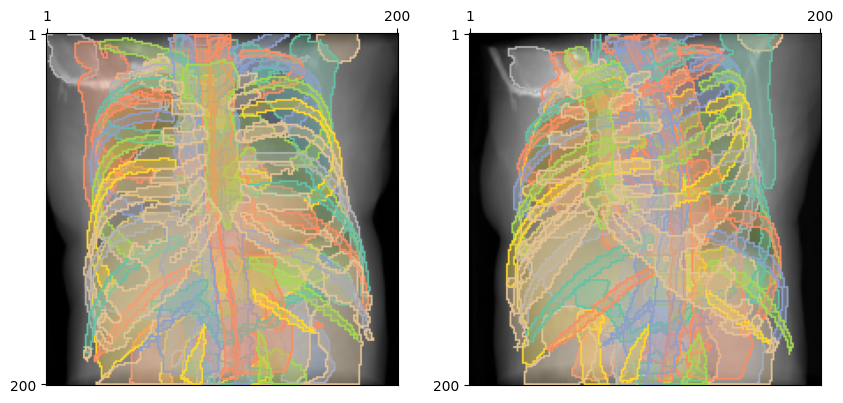

In [13]:
img = torch_render(subject, k_inv, rt_inv, sdd, 200, 200)
print(img.shape)

plot_drr(img)
plt.show()

In [14]:
%timeit torch_render(subject, k_inv, rt_inv, sdd, 200, 200)

4.54 ms ± 586 ns per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [9]:
from nanodrr.warp import render as warp_render

Warp 1.13.0.dev0 initialized:
   CUDA Toolkit 12.8, Driver 12.9
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX 6000 Ada Generation" (47 GiB, sm_89, mempool enabled)
   Kernel cache:
     /data/vision/polina/users/vivekg/xdg-cache/warp/1.13.0.dev0


Module nanodrr.warp.render 6b32b1b load on device 'cuda:0' took 5346.81 ms  (compiled)
torch.Size([2, 119, 200, 200])


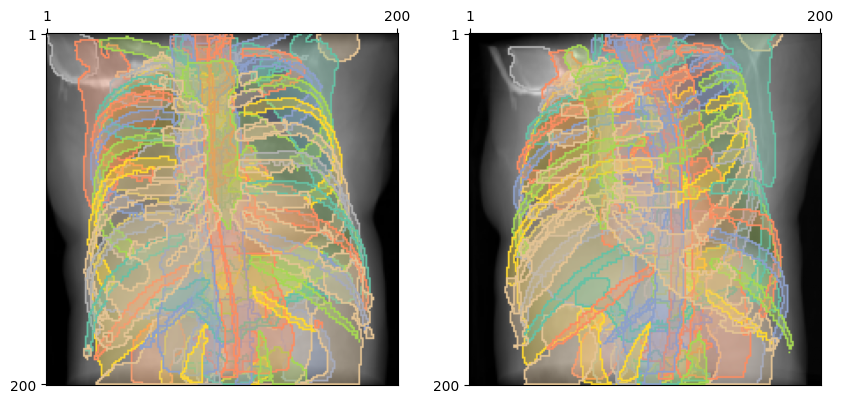

In [10]:
img = warp_render(subject, k_inv, rt_inv, sdd, 200, 200)
print(img.shape)

plot_drr(img)
plt.show()

In [11]:
%timeit warp_render(subject, k_inv, rt_inv, sdd, 200, 200)

807 μs ± 1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [9]:
import numpy as np
import warp as wp

wp.init()


@wp.struct
class WarpSubject:
    image: wp.Texture3D
    label: wp.Texture3D
    world2voxel: wp.mat44
    nx: int
    ny: int
    nz: int


@wp.struct
class Camera:
    k_inv: wp.mat33
    cam2world: wp.mat44
    sdd: float
    height: int
    width: int


@wp.kernel
def _render(
    subject: WarpSubject,
    cameras: wp.array(dtype=Camera),
    cam2voxels: wp.array(dtype=wp.mat44),
    n_samples: int,
    output: wp.array(dtype=float, ndim=3),  # [B, n_labels, n_pixels]
):
    tid = wp.tid()
    n_pixels = cameras[0].height * cameras[0].width
    b = tid // n_pixels
    ray_idx = tid % n_pixels

    camera = cameras[b]
    cam2voxel = cam2voxels[b]

    u = float(ray_idx % camera.width) + 0.5
    v = float(ray_idx // camera.width) + 0.5
    uv = wp.vec3(u, v, 1.0)

    source_cam = wp.vec3(0.0, 0.0, 0.0)
    target_cam = camera.sdd * wp.mul(camera.k_inv, uv)

    n_intervals = float(n_samples - 1)
    step_size = wp.length(target_cam * (1.0 / n_intervals))

    source = wp.transform_point(cam2voxel, source_cam)
    target = wp.transform_point(cam2voxel, target_cam)

    delta = (target - source) * (1.0 / n_intervals)

    t_min = float(0.0)
    t_max = float(1.0)
    for axis in range(3):
        d = target[axis] - source[axis]
        bound = float(subject.nx) if axis == 0 else (float(subject.ny) if axis == 1 else float(subject.nz))
        if wp.abs(d) > 1e-6:
            ta = (float(0.0) - source[axis]) / d
            tb = (bound - source[axis]) / d
            t_min = wp.max(t_min, wp.min(ta, tb))
            t_max = wp.min(t_max, wp.max(ta, tb))

    if t_min >= t_max:
        return

    i_min = int(wp.max(wp.floor(t_min * n_intervals), float(0)))
    i_max = int(wp.min(wp.ceil(t_max * n_intervals), n_intervals))

    pos = source + delta * float(i_min)

    for i in range(i_min, i_max):
        intensity = wp.texture_sample(subject.image, pos, dtype=float) * step_size
        label = int(wp.texture_sample(subject.label, pos, dtype=float))
        output[b, label, ray_idx] += intensity
        pos = pos + delta


def make_camera(k_inv, cam2world, sdd, height, width) -> Camera:
    c = Camera()
    c.k_inv = wp.mat33(k_inv)
    c.cam2world = wp.mat44(cam2world)
    c.sdd = float(sdd)
    c.height = height
    c.width = width
    return c


def drr(
    subject: WarpSubject,
    cameras: list[Camera],
    n_samples: int = 500,
    n_labels: int = 120,
) -> wp.array:
    B = len(cameras)
    height = cameras[0].height
    width = cameras[0].width
    n_pixels = height * width

    wp_cameras = wp.array(cameras, dtype=Camera)
    wp_cam2voxels = wp.array(
        [wp.mat44(subject.world2voxel) * wp.mat44(c.cam2world) for c in cameras],
        dtype=wp.mat44,
    )
    output = wp.zeros((B, n_labels, n_pixels), dtype=float)

    wp.launch(
        kernel=_render,
        dim=B * n_pixels,
        inputs=[subject, wp_cameras, wp_cam2voxels, n_samples],
        outputs=[output],
    )
    return output


D, H, W = subject.image.cpu().squeeze().numpy().shape
s = WarpSubject()
s.image = wp.Texture3D(
    subject.image.cpu().squeeze().numpy(), normalized_coords=False, address_mode=wp.TextureAddressMode.BORDER
)
s.label = wp.Texture3D(
    subject.label.cpu().squeeze().numpy(),
    normalized_coords=False,
    address_mode=wp.TextureAddressMode.BORDER,
    filter_mode=wp.TextureFilterMode.CLOSEST,
)
s.world2voxel = wp.mat44(subject.world_to_voxel)
s.nz, s.ny, s.nx = D, H, W

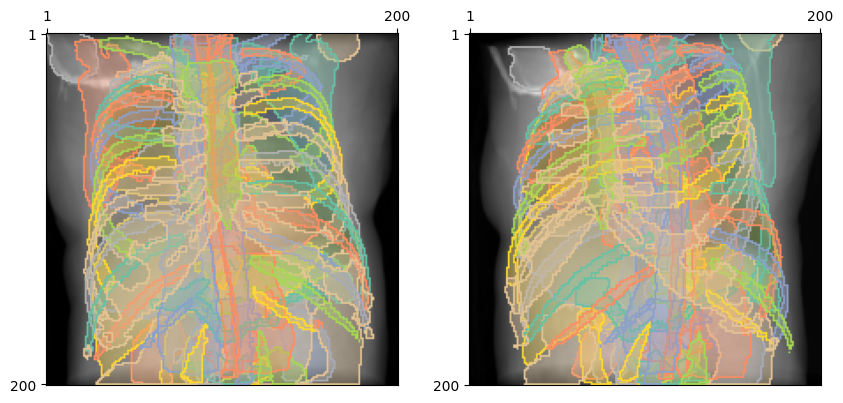

In [10]:
import matplotlib.pyplot as plt

cameras = [make_camera(k_inv, rt_inv[[0]], sdd, 200, 200), make_camera(k_inv, rt_inv[[1]], sdd, 200, 200)]
img = drr(s, cameras, n_samples=500)
img = torch.from_numpy(img.numpy().reshape(2, 120, 200, 200))
plot_drr(img)
plt.show()

In [11]:
%timeit drr(s, cameras)

687 μs ± 370 ns per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [28]:
import numpy as np
import torch
import warp as wp
from jaxtyping import Float

from nanodrr.data import Subject

wp.init()


@wp.struct
class WarpSubject:
    image: wp.Texture3D
    label: wp.Texture3D
    world2voxel: wp.mat44
    nx: int
    ny: int
    nz: int


@wp.func
def _make_tgt(
    k_inv: wp.mat33,
    sdd: float,
    ray_idx: int,
    width: int,
) -> wp.vec3:
    u = float(ray_idx % width) + 0.5
    v = float(ray_idx // width) + 0.5
    uv = wp.vec3(u, v, 1.0)
    return sdd * wp.mul(k_inv, uv)


@wp.kernel
def _render(
    subject: WarpSubject,
    k_inv: wp.array(dtype=wp.mat33),
    sdd: wp.array(dtype=float),
    height: int,
    width: int,
    cam2voxel: wp.array(dtype=wp.mat44),
    n_samples: int,
    output: wp.array(dtype=float, ndim=3),  # [B, n_labels, n_pixels]
):
    tid = wp.tid()
    n_pixels = height * width
    b = tid // n_pixels
    ray_idx = tid % n_pixels

    source_cam = wp.vec3(0.0, 0.0, 0.0)
    target_cam = _make_tgt(k_inv[b], sdd[b], ray_idx, width)

    n_intervals = float(n_samples - 1)
    step_size = wp.length(target_cam * (1.0 / n_intervals))

    source = wp.transform_point(cam2voxel[b], source_cam)
    target = wp.transform_point(cam2voxel[b], target_cam)

    delta = (target - source) * (1.0 / n_intervals)

    t_min = float(0.0)
    t_max = float(1.0)
    for axis in range(3):
        d = target[axis] - source[axis]
        bound = float(subject.nx) if axis == 0 else (float(subject.ny) if axis == 1 else float(subject.nz))
        if wp.abs(d) > 1e-6:
            ta = (float(0.0) - source[axis]) / d
            tb = (bound - source[axis]) / d
            t_min = wp.max(t_min, wp.min(ta, tb))
            t_max = wp.min(t_max, wp.max(ta, tb))

    if t_min >= t_max:
        return

    i_min = int(wp.max(wp.floor(t_min * n_intervals), float(0)))
    i_max = int(wp.min(wp.ceil(t_max * n_intervals), n_intervals))

    pos = source + delta * float(i_min)

    for i in range(i_min, i_max):
        intensity = wp.texture_sample(subject.image, pos, dtype=float) * step_size
        label = int(wp.texture_sample(subject.label, pos, dtype=float))
        output[b, label, ray_idx] += intensity
        pos = pos + delta


# --- Subject conversion ---

_wp_subject_cache: dict[int, tuple[Subject, WarpSubject]] = {}


def _to_wp_subject(s: Subject) -> WarpSubject:
    key = id(s)
    if key in _wp_subject_cache:
        return _wp_subject_cache[key][1]

    image_np = s.image.cpu().squeeze().numpy()
    label_np = s.label.cpu().squeeze().numpy()
    D, H, W = image_np.shape

    wp_subject = WarpSubject()
    wp_subject.image = wp.Texture3D(
        image_np,
        normalized_coords=False,
        address_mode=wp.TextureAddressMode.BORDER,
        filter_mode=wp.TextureFilterMode.LINEAR,
    )
    wp_subject.label = wp.Texture3D(
        label_np,
        normalized_coords=False,
        address_mode=wp.TextureAddressMode.BORDER,
        filter_mode=wp.TextureFilterMode.CLOSEST,
    )
    wp_subject.world2voxel = wp.mat44(s.world_to_voxel.cpu().numpy())
    wp_subject.nz = D
    wp_subject.ny = H
    wp_subject.nx = W

    _wp_subject_cache[key] = (s, wp_subject)
    return wp_subject


# --- Caches ---

_subject_registry: dict[int, WarpSubject] = {}

# keyed by (data_ptr, B) — stable for fixed k_inv/sdd across iterations
_k_inv_cache: dict[tuple, wp.array] = {}
_sdd_cache: dict[tuple, wp.array] = {}

# keyed by (subject_ptr, B, height, width, n_labels)
_output_cache: dict[tuple, tuple[wp.array, torch.Tensor]] = {}


def _get_wp_k_inv(k_inv_t: torch.Tensor) -> wp.array:
    key = (k_inv_t.data_ptr(), k_inv_t.shape[0])
    if key not in _k_inv_cache:
        B = k_inv_t.shape[0]
        _k_inv_cache[key] = wp.array(
            [wp.mat33(k_inv_t[b].cpu().numpy()) for b in range(B)],
            dtype=wp.mat33,
        )
    return _k_inv_cache[key]


def _get_wp_sdd(sdd_t: torch.Tensor) -> wp.array:
    key = (sdd_t.data_ptr(), sdd_t.shape[0])
    if key not in _sdd_cache:
        B = sdd_t.shape[0]
        _sdd_cache[key] = wp.array(
            [float(sdd_t[b].item()) for b in range(B)],
            dtype=float,
        )
    return _sdd_cache[key]


def _get_wp_output(subject_ptr: int, B: int, height: int, width: int, n_labels: int) -> tuple[wp.array, torch.Tensor]:
    cache_key = (subject_ptr, B, height, width, n_labels)
    if cache_key not in _output_cache:
        wp_output = wp.zeros((B, n_labels, height * width), dtype=float)
        # cache the torch view — wp.to_torch is zero-copy but has Python overhead
        torch_output = wp.to_torch(wp_output)
        _output_cache[cache_key] = (wp_output, torch_output)
    wp_output, torch_output = _output_cache[cache_key]
    wp_output.zero_()
    return wp_output, torch_output


# --- Custom ops ---


@torch.library.custom_op("drr::render_forward", mutates_args=())
def _render_forward(
    cam2world_t: torch.Tensor,  # [B, 4, 4]
    k_inv_t: torch.Tensor,  # [B, 3, 3]
    sdd_t: torch.Tensor,  # [B]
    height: int,
    width: int,
    n_samples: int,
    n_labels: int,
    subject_ptr: int,
) -> torch.Tensor:
    subject = _subject_registry[subject_ptr]
    B = cam2world_t.shape[0]

    # cam2voxel: compute on GPU via torch, convert via wp.from_torch — no CPU round-trip
    world2voxel_t = torch.as_tensor(
        np.array(subject.world2voxel).reshape(4, 4),
        dtype=cam2world_t.dtype,
        device=cam2world_t.device,
    )
    cam2voxel_t = (world2voxel_t.unsqueeze(0).expand(B, -1, -1) @ cam2world_t).contiguous()
    wp_cam2voxel = wp.from_torch(cam2voxel_t, dtype=wp.mat44)

    wp_k_inv = _get_wp_k_inv(k_inv_t)
    wp_sdd = _get_wp_sdd(sdd_t)
    wp_output, torch_output = _get_wp_output(subject_ptr, B, height, width, n_labels)

    wp.launch(
        kernel=_render,
        dim=B * height * width,
        inputs=[subject, wp_k_inv, wp_sdd, height, width, wp_cam2voxel, n_samples],
        outputs=[wp_output],
    )

    return torch_output.clone()


@_render_forward.register_fake
def _(cam2world_t, k_inv_t, sdd_t, height, width, n_samples, n_labels, subject_ptr):
    B = cam2world_t.shape[0]
    return torch.empty(B, n_labels, height * width, dtype=torch.float32)


@torch.library.custom_op("drr::render_backward", mutates_args=())
def _render_backward(
    cam2world_t: torch.Tensor,
    k_inv_t: torch.Tensor,
    sdd_t: torch.Tensor,
    height: int,
    width: int,
    n_samples: int,
    n_labels: int,
    subject_ptr: int,
    adj_output: torch.Tensor,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    subject = _subject_registry[subject_ptr]
    B = cam2world_t.shape[0]

    # cam2voxel with grad — pre-allocate grad to avoid deferred allocation sync
    world2voxel_t = torch.as_tensor(
        np.array(subject.world2voxel).reshape(4, 4),
        dtype=cam2world_t.dtype,
        device=cam2world_t.device,
    )
    cam2voxel_t = (world2voxel_t.unsqueeze(0).expand(B, -1, -1) @ cam2world_t).contiguous()
    cam2voxel_grad_t = torch.zeros_like(cam2voxel_t)  # pre-allocate grad
    wp_cam2voxel = wp.from_torch(cam2voxel_t, dtype=wp.mat44, requires_grad=True)
    wp_cam2voxel.grad = wp.from_torch(cam2voxel_grad_t, dtype=wp.mat44)

    # k_inv and sdd — pre-allocate grads
    wp_k_inv = wp.array(
        [wp.mat33(k_inv_t[b].cpu().numpy()) for b in range(B)],
        dtype=wp.mat33,
        requires_grad=True,
    )
    wp_k_inv.grad = wp.zeros_like(wp_k_inv)

    wp_sdd = wp.array(
        [float(sdd_t[b].item()) for b in range(B)],
        dtype=float,
        requires_grad=True,
    )
    wp_sdd.grad = wp.zeros_like(wp_sdd)

    wp_output, _ = _output_cache[(subject_ptr, B, height, width, n_labels)]
    wp_adj_output = wp.from_torch(adj_output.contiguous(), requires_grad=False)

    wp.launch(
        kernel=_render,
        dim=B * height * width,
        inputs=[subject, wp_k_inv, wp_sdd, height, width, wp_cam2voxel, n_samples],
        outputs=[wp_output],
        adj_inputs=[None, wp_k_inv.grad, wp_sdd.grad, None, None, wp_cam2voxel.grad, None],
        adj_outputs=[wp_adj_output],
        adjoint=True,
    )

    return wp.to_torch(wp_cam2voxel.grad), wp.to_torch(wp_k_inv.grad), wp.to_torch(wp_sdd.grad)


@_render_backward.register_fake
def _(cam2world_t, k_inv_t, sdd_t, height, width, n_samples, n_labels, subject_ptr, adj_output):
    return torch.empty_like(cam2world_t), torch.empty_like(k_inv_t), torch.empty_like(sdd_t)


def _backward(ctx, adj_output):
    adj_cam2world, adj_k_inv, adj_sdd = _render_backward(
        ctx.cam2world_t,
        ctx.k_inv_t,
        ctx.sdd_t,
        ctx.height,
        ctx.width,
        ctx.n_samples,
        ctx.n_labels,
        ctx.subject_ptr,
        adj_output,
    )
    # order: cam2world_t, k_inv_t, sdd_t, height, width, n_samples, n_labels, subject_ptr
    return adj_cam2world, adj_k_inv, adj_sdd, None, None, None, None, None


def _setup_context(ctx, inputs, output):
    ctx.cam2world_t, ctx.k_inv_t, ctx.sdd_t, ctx.height, ctx.width, ctx.n_samples, ctx.n_labels, ctx.subject_ptr = (
        inputs
    )


_render_forward.register_autograd(_backward, setup_context=_setup_context)


# --- Public API ---


def render(
    subject: Subject,
    k_inv: Float[torch.Tensor, "B 3 3"],
    rt_inv: Float[torch.Tensor, "B 4 4"],
    sdd: Float[torch.Tensor, "B"],
    height: int,
    width: int,
    n_samples: int = 500,
    src: Float[torch.Tensor, "B (H W) 3"] | None = None,
    tgt: Float[torch.Tensor, "B (H W) 3"] | None = None,
    n_labels: int | None = None,
) -> Float[torch.Tensor, "B n_labels H W"]:
    """Differentiable ray marching through a volume and optional labelmap.

    Casts rays from an X-ray source through a 3D volume and integrates sampled
    intensities along each ray to produce a synthetic radiograph. The integration
    is performed per-structure, yielding one channel per label class.

    Args:
        subject: The volume to render.
        k_inv: Inverse intrinsic camera matrix. Shape ``(B, 3, 3)``.
        rt_inv: Camera-to-world extrinsic matrix. Shape ``(B, 4, 4)``.
        sdd: Source-to-detector distance in mm. Shape ``(B,)``.
        height: Output image height in pixels.
        width: Output image width in pixels.
        n_samples: Number of samples along each ray.
        src: Ignored. Accepted for API compatibility with the PyTorch backend.
        tgt: Ignored. Accepted for API compatibility with the PyTorch backend.
            Ray endpoints are computed per-thread inside the kernel via ``_make_tgt``.
        n_labels: Number of label classes. Defaults to ``subject.n_classes``.

    Returns:
        Rendered radiograph of shape ``(B, n_labels, H, W)``.
    """
    if n_labels is None:
        n_labels = subject.n_classes

    wp_subject = _to_wp_subject(subject)
    subject_ptr = id(wp_subject)
    _subject_registry[subject_ptr] = wp_subject

    out = _render_forward(
        rt_inv,
        k_inv,
        sdd,
        height,
        width,
        n_samples,
        n_labels,
        subject_ptr,
    )  # [B, n_labels, n_pixels]

    return out.reshape(-1, n_labels, height, width)

In [31]:
from nanodrr.warp import render

Module nanodrr.warp.render 9c039b9 load on device 'cuda:0' took 2.13 ms  (cached)


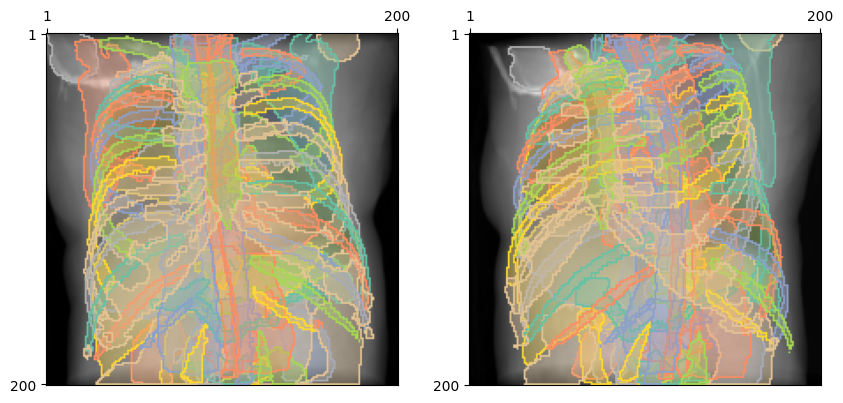

In [32]:
img = render(subject, k_inv.expand(2, 3, 3), rt_inv, sdd.expand(2, 1, 1), 200, 200)

plot_drr(img)
plt.show()

In [33]:
%timeit render(subject, k_inv.expand(2, 3, 3), rt_inv, sdd.expand(2, 1, 1), 200, 200)

806 μs ± 1.36 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
